In [ ]:
def z_from_slice(slice):
    lamda0 = 1215.670
    lamda = 3470 + (slice - 1.) * 2.
    z = (lamda - lamda0) / lamda0
    
    return z

In [ ]:
# Column names
COL_RA = "RA"
COL_DEC = "DEC"
COL_z = "z"
out_dir = "/data/hetdex/u/bgrashey/data_/"        
name = "test.fits"

from astropy.table import Table
import os
import numpy as np
from tools.EW import Measurements
from astropy.io import fits
from astropy.coordinates import SkyCoord

# catalog:
table_path = "/data/hetdex/u/bgrashey/data_/missing_mawatari_sources.fits"    
tbl = Table.read(table_path)
Catalog = tbl.to_pandas()
Catalog = Catalog.reset_index(drop=True)

directory = "/data/hetdex/u/mxhf/VDFI/VirusDeep/stackmf/ssa22_fullfp/"
file_stack = "ssa22_fullfp_stack.fits"
stack = os.path.join(directory, file_stack)
cube = fits.open(stack, memmap=True)
data = cube[0].section
header = cube[0].header

hsc_file = "/data/hetdex/u/mxhf/VDFI/joint/ssa22_hsc_pdr3_wide.fits"
with fits.open(hsc_file) as hdul:
    hsc_df = Table(hdul[1].data).to_pandas()
hsc_coords = SkyCoord(ra=hsc_df["ra"].values, 
                      dec=hsc_df["dec"].values, 
                      unit="deg", frame="icrs")        

# Neue Spalten als Listen initialisieren
new_cols = {
    "REDSHIFT": [], "EW": [], "EW_OBS": [], "EW_ERR": [],
    "FLUX": [], "FLUX_ERR": [], "CONT": [], "CONT_ERR": []
}

N = len(Catalog[COL_RA])
for n in range(N):
    print(f"\nInitialising Object {n+1}/{N}")
    
    try:
        coords = (
            Catalog[COL_RA][n],
            Catalog[COL_DEC][n],
            Catalog[COL_z][n]
        )
        
        meas = Measurements(data, header, coords, hsc_df, hsc_coords)
        EW_OBS, EW, EW_ERR, F, F_ERR, C, C_ERR, z = meas.measure_ew()
        
        new_cols["REDSHIFT"].append(z)
        new_cols["EW"].append(EW)
        new_cols["EW_OBS"].append(EW_OBS)
        new_cols["EW_ERR"].append(EW_ERR)
        new_cols["FLUX"].append(F)
        new_cols["FLUX_ERR"].append(F_ERR)
        new_cols["CONT"].append(C)
        new_cols["CONT_ERR"].append(C_ERR)
        
        print("done")
    
    except Exception as e:
        print(f"Object {n} failed: {e}")
        for key in new_cols:
            new_cols[key].append(np.nan)

# Neue Spalten an den originalen Katalog hängen
for col_name, values in new_cols.items():
    tbl[col_name] = np.array(values, dtype="f8")

# Klassifikations-Wahrscheinlichkeit berechnen
from line_classifier.probs.classification_prob import source_prob
import configparser

config_file = "/data/hetdex/u/bgrashey/notebooks/line_prob/hetdex_line_classification/tests/data/universe.cfg"
flim_file = "/data/hetdex/u/bgrashey/notebooks/Line_flux_limit_5_sigma_baseline.dat"

config = configparser.ConfigParser()
config.read(config_file)

z   = tbl["REDSHIFT"]
F   = tbl["FLUX"]
E   = tbl["FLUX_ERR"]
eq  = tbl["EW_OBS"]
eq_E = tbl["EW_ERR"]

p = source_prob(config, [1]*len(z), [1]*len(z), z, F, E, eq, eq_E,
                None, None, None, None, None, flim_file, ignore_noise=True)
tbl["PROB"] = p

out_path = os.path.join(out_dir, name)
tbl.write(out_path, overwrite=True)

cube.close()

In [ ]:
print("done")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Lade Cube: /data/hetdex/u/bgrashey/cubes/test.fits
  Shape: (1036, 2478, 2260)
  Erzeuge 100 Cutouts ...


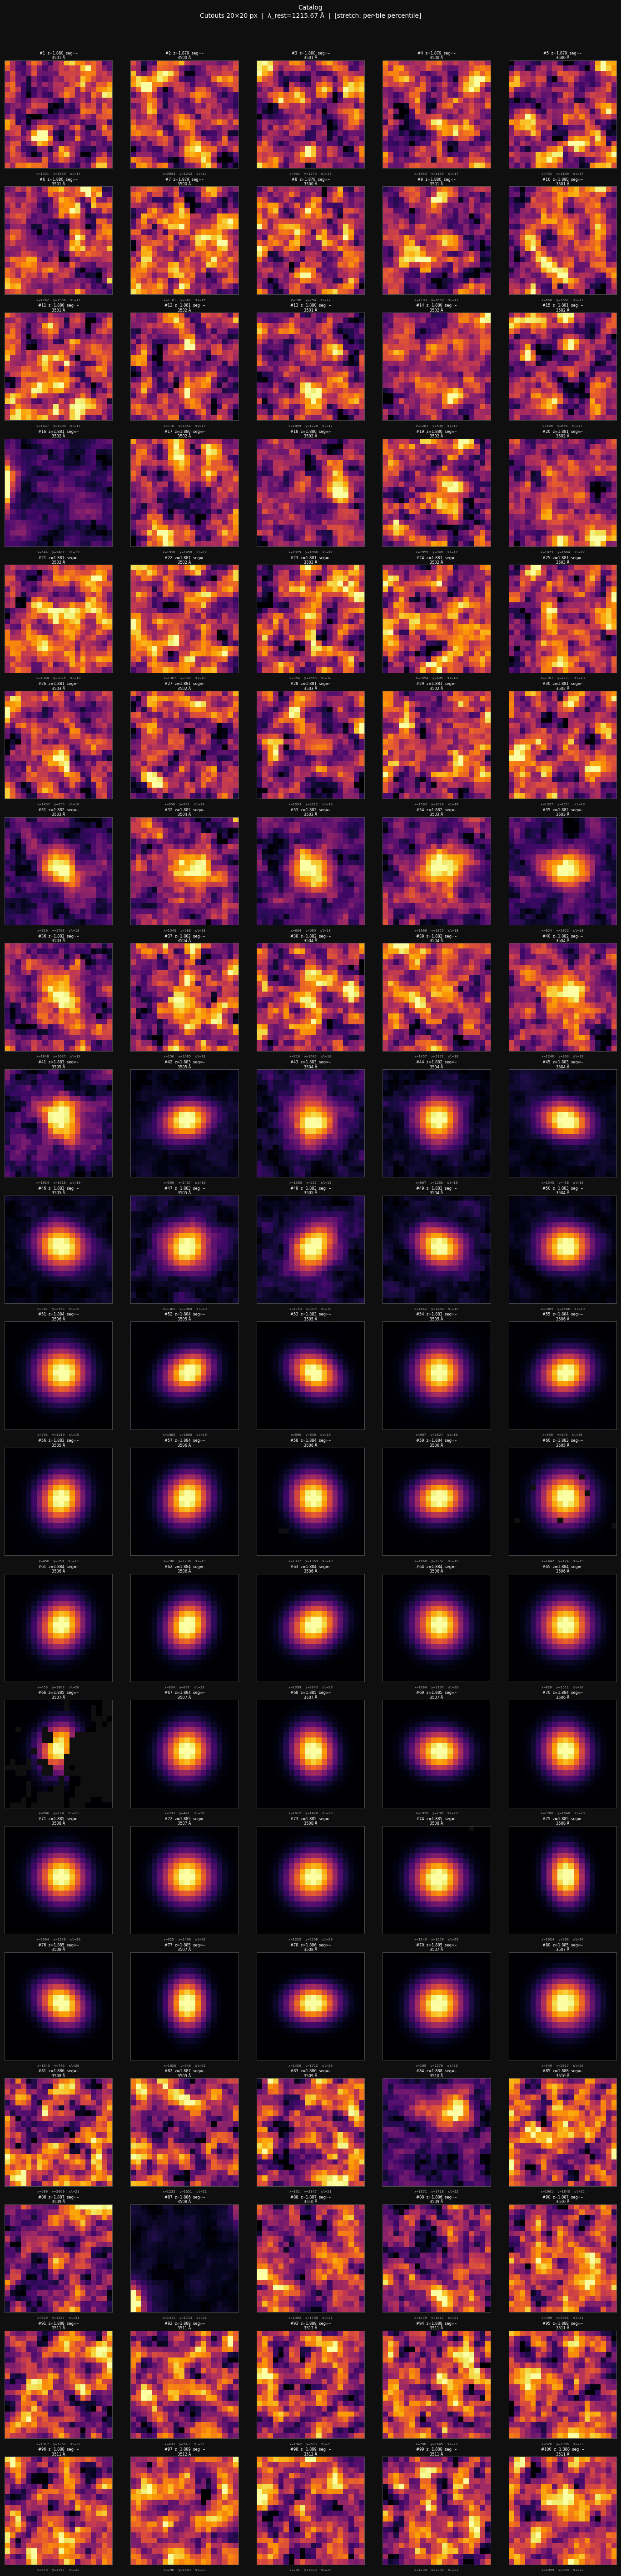

  Gespeichert: ./test_cutouts.pdf


In [23]:
%load_ext autoreload
%autoreload 2

from tools.functions import plot_cutout_grid
from astropy.table import Table

cube = "/data/hetdex/u/bgrashey/cubes/test.fits"
#sn = "/data/hetdex/u/bgrashey/cubes/sn_cube.fits"
missed = Table.read("/data/hetdex/u/bgrashey/data_/injected_sources.fits")

plot_cutout_grid(
     missed,
     cube,
     "./test_cutouts.pdf",
     col_ra = "ra",
     col_dec = "dec",
     cutout_size = 20,
     num_cutouts = 100,
     use_fixed_stretch = False,      
     vmin_fixed      = -300,
     vmax_fixed      =  300,
     cmap            = "inferno",
 )

In [2]:
def redshift_to_slice(redshift):
        lya_obs = 1216.0 * (1.0 + redshift)
        slice_ = round(1 + (lya_obs - 3470) / 2)
        return slice_


In [5]:
print(redshift_to_slice(2.1))

151


In [21]:
from tools.functions import completeness_analysis

injected = "/data/hetdex/u/bgrashey/data_/injected_sources.fits"
detected = "/data/hetdex/u/bgrashey/cubes/gefundene_quellen.fits"

completeness_analysis(injected,
                      injected#detected
                     )

In [22]:
from astropy.table import Table, vstack

Table.read("/data/hetdex/u/bgrashey/data_/injected_sources_flagged.fits")

id,chunk_index,bin_index,ra,dec,z,flux,detected
int64,int64,int64,float64,float64,float64,float64,bool
0,1,0,334.2798900942182,0.3785186811657213,1.879865838944911,0.0699800574047025,True
1,1,0,334.1795942074893,0.2788970640919039,1.8794166829097416,0.05309534959511907,True
2,1,0,334.33108188309404,0.28278708551508647,1.8796499511113387,0.057006599735358064,True
3,1,0,334.3185493815647,0.2640633039035383,1.8794767271897306,0.06806343641324043,True
4,1,0,334.3602506546174,0.27167450341902494,1.8793292063938187,0.09268861683370393,True
5,1,0,334.2895312061405,0.3781436354905536,1.8798684312605247,0.0840622977933396,True
6,1,0,334.3007688450945,0.23710645319078472,1.8790996971835776,0.06684231910274095,True
7,1,0,334.4375694621183,0.21109997841383873,1.8792954855214812,0.07724953278469542,True
8,1,0,334.3004322863644,0.33694974457364607,1.8795490597061173,0.08352254637578624,True


In [ ]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt

cat = Table.read("/data/hetdex/u/bgrashey/data_/injected_sources_flagged.fits")

bins = [(0.05, 0.1), (0.1, 0.5), (0.5, 1), (1, 10), (10, 100),
        (100,1000), (1000, 2000), (2000, 10000)]

completeness = []
flux = []

for n in range(len(bins)):
    mask = cat["bin_index"] == n
    det = cat[mask]["detected"] == True
    c = det.sum() / mask.sum()
    completeness.append(c)
    flux_ = np.mean(*bins[n])
    flux.append(flux_)

    
        
plt.scatter(flux, completeness)
plt.xlabel("Flux in counts")
plt.ylabel("Completeness")
plt.show()